# Harmonic Excitation Frequency Sweep

This notebook runs a finite-element sweep over excitation frequency using **harmonic** input:

\[
v_{exc}(t) = A\sin(2\pi f_{exc} t)
\]

Edit the sweep lists in Cell 2, then run all cells.

In [26]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import sys
import json
import pickle
from datetime import datetime
from pathlib import Path

import numpy as np
from joblib import Parallel, delayed


def find_project_root(start: Path) -> Path:
    """Find project root that contains the Modeling package."""
    for p in [start, *start.parents]:
        if (p / "Modeling").exists():
            return p
    raise RuntimeError("Could not locate project root containing 'Modeling'.")


project_root = find_project_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Modeling.models.beam_properties import PiezoBeamParams
from Modeling.models import FE_helpers
import Modeling.models.FE3 as FE_module
import matplotlib.pyplot as plt
from scipy.signal import chirp

In [27]:
# -----------------------------
# Sweep setup (edit this cell)
# -----------------------------
SAVE_PREFIX = "freq_sweep_hardening"
NO_CORES = 10
sim_dat_dir = Path.cwd() / "sim_dat"
sim_dat_dir.mkdir(parents=True, exist_ok=True)

params_fe = PiezoBeamParams(hp=0.252e-3, hs=0.51e-3, d31=-1.45e-10, eps_r=1700)
BASE_PARAMS = {"K_p": 0.018, "K_i": 1820, "K_c": 3e10, "R_c": 1e3}

amp = 50.0
freq_list = [2450.0, 2475.0, 2500.0, 2525.0, 2550.0]

f_max = max(freq_list)
dt = 2/ (f_max * 80)
t_end = 5000 / f_max
t1 = 0.1 * t_end
f0 = 500


print(f"Sweep points: {len(freq_list)}")
print(f"dt = {dt:.3e} s, t_end = {t_end:.3f} s")

Sweep points: 5
dt = 9.804e-06 s, t_end = 1.961 s


In [28]:
def run_one(f_exc):
    fe = FE_module.PiezoBeamFE(params_fe)

    # Start from 0 Hz and sweep up to f over [0, t1], then continue at f.
    # solve_newmark may evaluate v_exc on arrays, so keep it vectorized.
    def v_exc(t):
        t_arr = np.asarray(t)
        swept = amp * chirp(t_arr, f0=0, f1=f_exc, t1=t1, method="linear")
        steady = amp * np.cos(2 * np.pi * f_exc * t_arr)
        values = np.where(t_arr < t1, swept, steady)
        return values.item() if np.isscalar(t) else values

    ode = fe.build_ode_system(
        j_exc=30,
        K_p=BASE_PARAMS["K_p"],
        K_i=BASE_PARAMS["K_i"],
        K_c=BASE_PARAMS["K_c"],
        R_c=BASE_PARAMS["R_c"],
        v_exc=v_exc,
    )

    out = FE_helpers.solve_newmark(
        ode=ode,
        dt=dt,
        t_end=t_end,
        beta=0.25,
        gamma=0.5,
        newton_tol=1e-6,
        newton_maxiter=20,
        x0=np.zeros(ode.M.shape[0]),
        x_dot0=np.zeros(ode.M.shape[0]),
        do_spectral=True,
    )

    return {"f_exc": f_exc, **out}

results = Parallel(n_jobs=len(freq_list), verbose=12)(delayed(run_one)(f_exc) for f_exc in freq_list)


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


KeyboardInterrupt: 

In [ ]:
r = results[-1]
r.keys()
r['spectral']['FRF'].shape


(10001,)

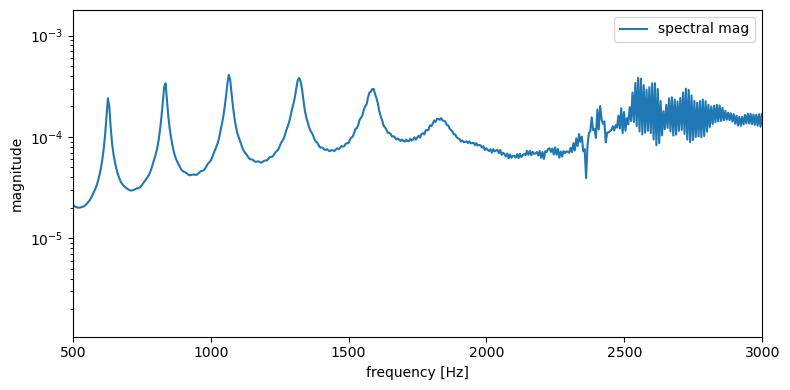

In [ ]:
plt.figure(figsize=(8, 4))
plt.semilogy(r['spectral']['freq'], np.abs(r['spectral']['FRF']), label='spectral mag')
plt.xlabel('frequency [Hz]')
plt.ylabel('magnitude')
plt.xlim(500, 3000)
plt.legend()
plt.tight_layout()
plt.show()

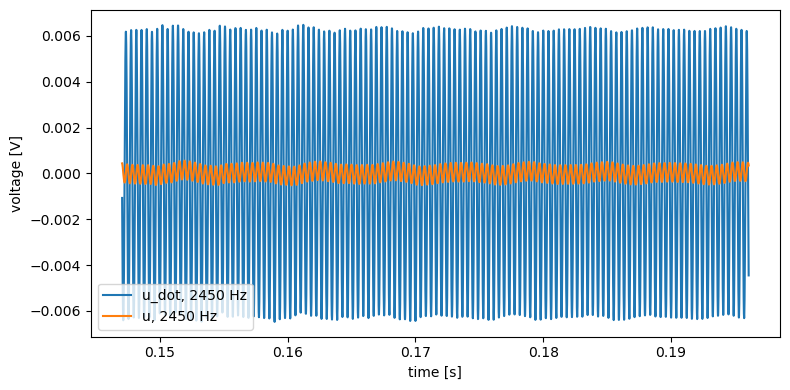

In [ ]:

plt.figure(figsize=(8, 4))
mask = (results[0]["t"] >= t1*1.5) & (results[0]["t"] <= t_end)
r = results[0]
pos_idx = 120

plt.plot(r["t"][mask], r["u_dot"][mask, pos_idx], label=f'u_dot, {r["f_exc"]:.0f} Hz')
plt.plot(r["t"][mask], r["u"][mask, pos_idx]*1000, label=f'u, {r["f_exc"]:.0f} Hz')
plt.xlabel('time [s]')
plt.ylabel('voltage [V]')
plt.legend()
plt.tight_layout()
plt.show()


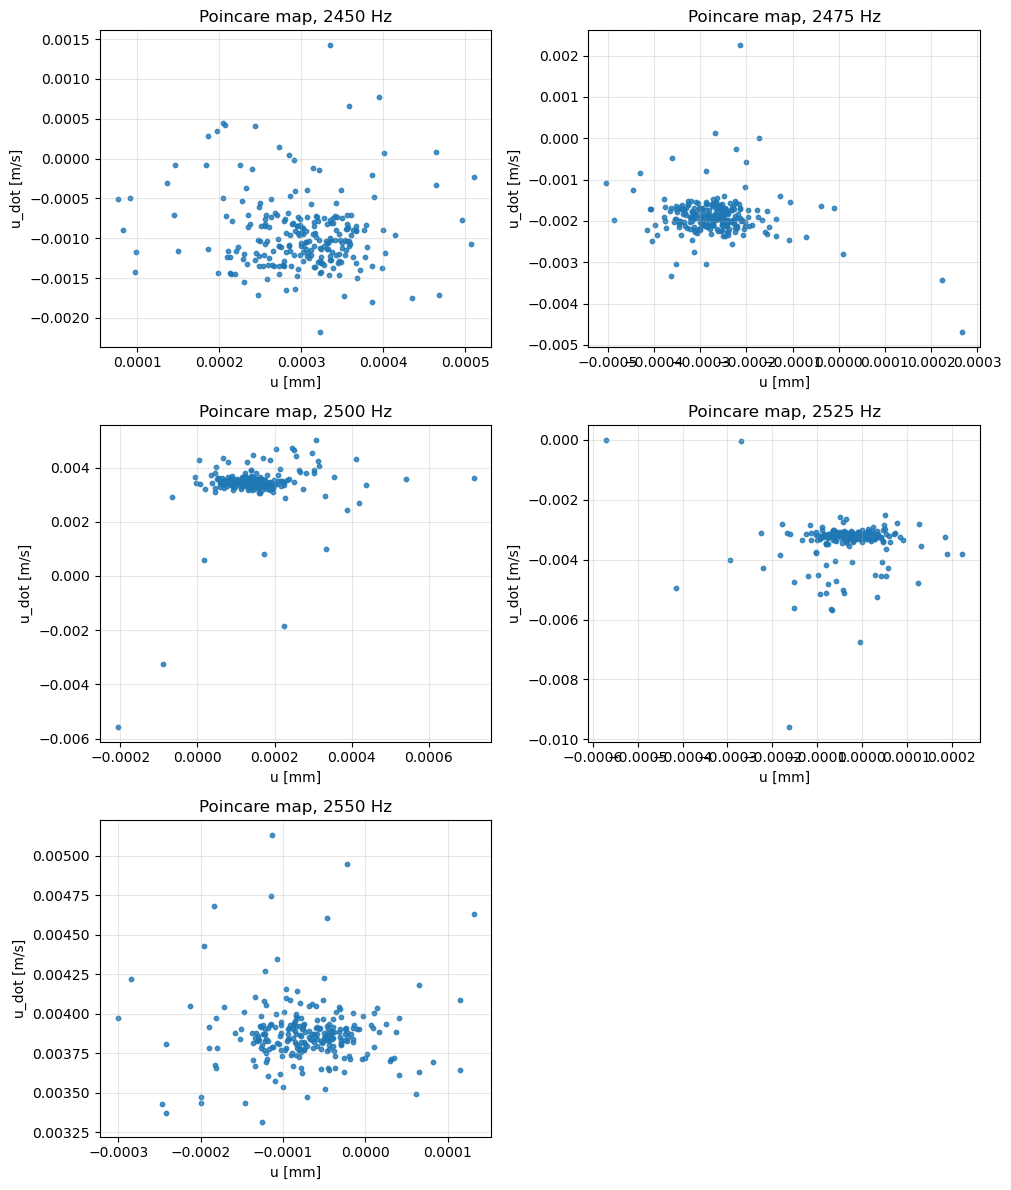

In [ ]:
# Poincare map for each excitation frequency
# Sample the response once per forcing period after the transient window.
pos_idx = 50
n_cols = 2
n_rows = int(np.ceil(len(results) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows), squeeze=False)

for ax, r in zip(axes.ravel(), results):
    t = r['t']
    T = 1.0 / r['f_exc']
    t_start = t1 + T * 200
    sample_times = np.arange(t_start, t[-1], T)
    sample_idx = np.searchsorted(t, sample_times)
    sample_idx = sample_idx[sample_idx < len(t)]

    x = r['u'][sample_idx, pos_idx] * 1000
    y = r['u_dot'][sample_idx, pos_idx]

    ax.scatter(x, y, s=10, alpha=0.8)
    ax.set_title(f'Poincare map, {r["f_exc"]:.0f} Hz')
    ax.set_xlabel('u [mm]')
    ax.set_ylabel('u_dot [m/s]')
    ax.grid(True, alpha=0.3)

for ax in axes.ravel()[len(results):]:
    ax.axis('off')

plt.tight_layout()
plt.show()